In [3]:
import math
import random
from typing import List, Optional, Tuple
import numpy as np
import torch
from tqdm import tqdm
import contextlib
from functools import partial
import matplotlib.pyplot as plt

In [4]:
# mps cuda stuff 
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


### Architecture

In [5]:
class Transformer(torch.nn.Module):
    def __init__(
        self,
        vocab_size: int,
        max_seq_len: int,
        d_model: int = 128,
        n_heads: int = 4,
        n_layers: int = 4,
        causal: bool = True,
        time_conditioning: bool = False,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.n_heads = n_heads
        self.max_seq_len = max_seq_len
        self.causal = causal
        self.time_conditioning = time_conditioning

        self.embed = torch.nn.Embedding(vocab_size, d_model)
        self.pos_embed = torch.nn.Embedding(max_seq_len, d_model)

        if self.time_conditioning:
            self.time_mlp = torch.nn.Sequential(
                torch.nn.Linear(1, d_model),
                torch.nn.SiLU(),
                torch.nn.Linear(d_model, d_model),
            )

        self.layers = torch.nn.ModuleList([
            torch.nn.ModuleDict({
                "attn": torch.nn.MultiheadAttention(d_model, n_heads, batch_first=True),
                "ln1": torch.nn.LayerNorm(d_model),
                "mlp": torch.nn.Sequential(
                    torch.nn.Linear(d_model, 4 * d_model),
                    torch.nn.GELU(),
                    torch.nn.Linear(4 * d_model, d_model),
                ),
                "ln2": torch.nn.LayerNorm(d_model),
            })
            for _ in range(n_layers)
        ])

        self.lm_head = torch.nn.Linear(d_model, vocab_size, bias=False)

    def _build_attn_mask(self, bsz: int, seqlen: int, device: torch.device, dtype: torch.dtype):
        if not self.causal:
            return None

        mask = torch.full((seqlen, seqlen), 0.0, device=device, dtype=dtype)
        mask = mask.masked_fill(
            torch.triu(torch.ones(seqlen, seqlen, device=device, dtype=torch.bool), diagonal=1),
            float("-inf"),
        )
        mask = mask.unsqueeze(0).expand(bsz * self.n_heads, seqlen, seqlen)
        return mask

    def _time_embed(self, t: torch.Tensor, bsz: int, device: torch.device, dtype: torch.dtype):
        """
        t: expected shape [bsz] or [bsz, 1]
        returns: [bsz, d_model]
        """
        if t is None:
            return None

        if t.dim() == 1:
            t = t[:, None]
        elif t.dim() != 2 or t.shape[1] != 1:
            raise ValueError(f"t must have shape [bsz] or [bsz, 1], got {tuple(t.shape)}")

        if t.shape[0] != bsz:
            raise ValueError(f"t batch size {t.shape[0]} does not match input batch size {bsz}")

        t = t.to(device=device, dtype=dtype)
        return self.time_mlp(t)

    def forward(self, input_ids: torch.Tensor, t: torch.Tensor = None) -> torch.Tensor:
        # input_ids: [bsz, seq]
        bsz, seqlen = input_ids.shape

        if seqlen > self.max_seq_len:
            raise ValueError(f"Sequence length {seqlen} exceeds max_seq_len={self.max_seq_len}")

        pos = torch.arange(seqlen, device=input_ids.device)
        x = self.embed(input_ids) + self.pos_embed(pos)[None, :, :]

        if t is not None:
            if not self.time_conditioning:
                raise ValueError("Received t, but time_conditioning=False")
            t_emb = self._time_embed(t, bsz=bsz, device=input_ids.device, dtype=x.dtype)  # [bsz, d_model]
            x = x + t_emb[:, None, :]  # broadcast over sequence length
        elif self.time_conditioning:
            raise ValueError("time_conditioning=True but no t was provided")

        attn_mask = self._build_attn_mask(
            bsz=bsz,
            seqlen=seqlen,
            device=input_ids.device,
            dtype=x.dtype,
        )

        for layer in self.layers:
            residual = x
            x = layer["ln1"](x)
            attn_out, _ = layer["attn"](
                x, x, x,
                attn_mask=attn_mask,
                need_weights=False,
            )
            x = residual + attn_out

            residual = x
            x = layer["ln2"](x)
            x = residual + layer["mlp"](x)

        logits = self.lm_head(x)
        return logits

### Data generation

In [6]:
class SudokuGenerator:
    def __init__(self, box_rows: int, box_cols: int):
        if box_rows <= 0 or box_cols <= 0:
            raise ValueError("box_rows and box_cols must be positive")

        self.box_rows = box_rows
        self.box_cols = box_cols
        self.n = box_rows * box_cols

    def make_base_grid(self, offset: int = 0) -> np.ndarray:
        '''
        Gives a base grid, e.g. for box_rows=2, box_cols=2: 
        1 2 3 4
        3 4 1 2
        2 1 4 3
        4 3 2 1
        '''
        n = self.n
        grid = np.zeros((n, n), dtype=int)
        for r in range(n):
            for c in range(n):
                grid[r, c] = ((r * self.box_cols + r // self.box_rows + c + offset) % n) + 1
        return grid

    def generate_solution(self, rng: random.Random | None = None) -> np.ndarray:
        '''
        Permutes by shuffling rows within row bands, shuffling row bands, shuffling columns within column stacks, shuffling column stacks, and optionally transposing.
        '''
        if rng is None:
            rng = random.Random()

        grid = self.make_base_grid()
        n = self.n

        # permute symbols
        symbols = list(range(1, n + 1))
        shuffled = symbols[:]
        rng.shuffle(shuffled)
        mapping = np.array([0] + shuffled)
        grid = mapping[grid]

        # shuffle rows within row bands
        row_order = []
        num_row_bands = n // self.box_rows
        for band in range(num_row_bands):
            # band becomes i*box_rows to (i+1)*box_rows - 1, e.g. 0-2, 3-5, 6-8 for box_rows=3
            rows = list(range(band * self.box_rows, (band + 1) * self.box_rows))
            # we shuffle the rows within this band, e.g. for band 0 we shuffle rows 0,1,2
            rng.shuffle(rows)
            row_order.extend(rows)
        grid = grid[row_order, :]

        # shuffle row bands: which shuffles the (0-2), (3-5), (6-8) sets of rows
        band_order = list(range(num_row_bands))
        rng.shuffle(band_order)
        row_order = []
        for band in band_order:
            row_order.extend(range(band * self.box_rows, (band + 1) * self.box_rows))
        grid = grid[row_order, :]

        # same idea for columns: shuffle cols within column stacks
        col_order = []
        num_col_stacks = n // self.box_cols
        for stack in range(num_col_stacks):
            cols = list(range(stack * self.box_cols, (stack + 1) * self.box_cols))
            rng.shuffle(cols)
            col_order.extend(cols)
        grid = grid[:, col_order]

        # shuffle column stacks
        stack_order = list(range(num_col_stacks))
        rng.shuffle(stack_order)
        col_order = []
        for stack in stack_order:
            col_order.extend(range(stack * self.box_cols, (stack + 1) * self.box_cols))
        grid = grid[:, col_order]

        if self.box_rows == self.box_cols and rng.random() < 0.5:
            grid = grid.T

        return grid

    def make_puzzle(self, clues: int, rng: random.Random | None = None) -> tuple[np.ndarray, np.ndarray]:
        '''
        Sets to 0 all but the specified number of clues, randomly distributed. Returns the puzzle and the solution.
        '''
        if rng is None:
            rng = random.Random()

        solution = self.generate_solution(rng)
        puzzle = solution.copy()

        total_cells = self.n * self.n
        if not (1 <= clues <= total_cells):
            raise ValueError(f"clues must be between 1 and {total_cells}")

        positions = [(r, c) for r in range(self.n) for c in range(self.n)]
        rng.shuffle(positions)

        cells_to_remove = total_cells - clues
        for r, c in positions[:cells_to_remove]:
            puzzle[r, c] = 0

        return puzzle, solution

    def make_batch(self, batch_size: int, clues: int, rng: random.Random | None = None) -> tuple[np.ndarray, np.ndarray]:
        if rng is None:
            rng = random.Random()

        puzzles = []
        solutions = []
        for _ in range(batch_size):
            puzzle, solution = self.make_puzzle(clues, rng)
            puzzles.append(puzzle)
            solutions.append(solution)

        return np.array(puzzles), np.array(solutions)

def is_valid(grid: np.ndarray, box_rows: int, box_cols: int) -> bool:
    grid = np.asarray(grid)
    n = box_rows * box_cols
    if grid.shape != (n, n):
        return False
    if np.any(grid < 1) or np.any(grid > n):
        return False
    required = set(range(1, n + 1))
    # validate that each row contains all numbers from 1 to n
    for r in range(n):
        if set(grid[r, :]) != required:
            return False
    # validate that each column contains all numbers from 1 to n
    for c in range(n):
        if set(grid[:, c]) != required:
            return False
    for r0 in range(0, n, box_rows):
        for c0 in range(0, n, box_cols):
            # validate that each block contains all numbers from 1 to n
            block = grid[r0:r0 + box_rows, c0:c0 + box_cols].ravel()
            if set(block) != required:
                return False
    return True


def is_batch_valid(grids: np.ndarray, box_rows: int, box_cols: int) -> np.ndarray:
    grids = np.asarray(grids)
    if grids.ndim != 3:
        raise ValueError("grids must have shape (batch, n, n)")
    return np.array([is_valid(grid, box_rows, box_cols) for grid in grids], dtype=bool)


def print_board(grid: np.ndarray, box_rows: int, box_cols: int) -> None:
    grid = np.asarray(grid)
    n = grid.shape[0]

    cell_width = len(str(n))
    horiz_unit = "-" * ((cell_width + 1) * box_cols + 1)
    horiz_line = "+".join([horiz_unit] * (n // box_cols))

    for r in range(n):
        if r % box_rows == 0:
            print("+" + horiz_line + "+")

        row_parts = []
        for c in range(n):
            val = "." if grid[r, c] == 0 else str(int(grid[r, c])).rjust(cell_width)
            row_parts.append(val)

            if (c + 1) % box_cols == 0 and c != n - 1:
                row_parts.append("|")

        print("| " + " ".join(row_parts) + " |")

    print("+" + horiz_line + "+")

In [7]:
sudoku_generator = SudokuGenerator(box_rows=3, box_cols=3)
puzzles, solutions = sudoku_generator.make_batch(batch_size=1, clues=30)
puzzle = puzzles[0]
solution = solutions[0]
print("Puzzle:")
print_board(puzzle, box_rows=3, box_cols=3)
print("\nSolution:")
print_board(solution, box_rows=3, box_cols=3)
# Check validity
print("\nIs the solution valid?", is_valid(solution, box_rows=3, box_cols=3))

Puzzle:
+-------+-------+-------+
| 4 . . | 1 3 . | 8 9 2 |
| . . 1 | . 9 . | 7 6 . |
| . . . | . . . | . . . |
+-------+-------+-------+
| . 5 . | . . 7 | 6 4 . |
| . . . | 3 . . | 9 . . |
| 7 . . | . . 1 | . 5 8 |
+-------+-------+-------+
| . 8 . | . . . | . 1 3 |
| . . . | 5 . 9 | . . . |
| 6 . . | 4 1 . | 5 8 . |
+-------+-------+-------+

Solution:
+-------+-------+-------+
| 4 6 7 | 1 3 5 | 8 9 2 |
| 5 3 1 | 8 9 2 | 7 6 4 |
| 2 9 8 | 7 6 4 | 1 3 5 |
+-------+-------+-------+
| 8 5 3 | 9 2 7 | 6 4 1 |
| 1 4 6 | 3 5 8 | 9 2 7 |
| 7 2 9 | 6 4 1 | 3 5 8 |
+-------+-------+-------+
| 9 8 5 | 2 7 6 | 4 1 3 |
| 3 1 4 | 5 8 9 | 2 7 6 |
| 6 7 2 | 4 1 3 | 5 8 9 |
+-------+-------+-------+

Is the solution valid? True


## Diffusion-style training setup

This section builds a Sudoku dataset, applies absorbing-mask diffusion training with annealed attention,
and provides two decoding policies: random unmask (onefile-style) and most-confident-first.


In [8]:
# Dataset + tokenization
box_rows, box_cols = 3, 3
n = box_rows * box_cols
seq_len = n * n

PAD_TOKEN_ID = 0  # unused here, but reserved
MASK_TOKEN_ID = n + 1  # 10 for 9x9
VOCAB_SIZE = n + 2      # digits 1..9 plus [MASK]
MAX_SEQ_LEN = seq_len

def board_to_seq(board: np.ndarray) -> np.ndarray:
    return board.reshape(-1)

def puzzle_to_src_mask(puzzle: np.ndarray) -> np.ndarray:
    # True where the puzzle has a fixed clue
    return (puzzle.reshape(-1) != 0)

class SudokuDiffusionDataset(torch.utils.data.Dataset):
    def __init__(self, puzzles: np.ndarray, solutions: np.ndarray):
        self.puzzles = puzzles
        self.solutions = solutions

    def __len__(self):
        return len(self.puzzles)

    def __getitem__(self, idx):
        puzzle = self.puzzles[idx]
        solution = self.solutions[idx]
        input_ids = torch.tensor(board_to_seq(solution), dtype=torch.long)
        src_mask = torch.tensor(puzzle_to_src_mask(puzzle), dtype=torch.bool)
        return {"input_ids": input_ids, "src_mask": src_mask}

def make_sudoku_dataset(batch_size: int, clues: int, seed: int = 123):
    rng = random.Random(seed)
    gen = SudokuGenerator(box_rows=box_rows, box_cols=box_cols)
    puzzles, solutions = gen.make_batch(batch_size=batch_size, clues=clues, rng=rng)
    return SudokuDiffusionDataset(puzzles, solutions), puzzles, solutions

train_dataset, puzzles, clues = make_sudoku_dataset(batch_size=1_000_000, clues=10, seed=42)
print('Train dataset size:', len(train_dataset))

Train dataset size: 1000000


In [9]:
def diffusion_step(model, input_ids, src_mask, noise_level, mask_token_id):
    batch_size, seqlen = input_ids.shape
    sampling_eps = 1e-3 # done to avoid division by zero when sigma is very small
    # sample between [sampling_eps, noise_level], where noise_level is the maximum noise level we want to train with
    t = (noise_level - sampling_eps) * torch.rand(batch_size, device=input_ids.device) + sampling_eps
    sigma = t
    # each token is masked with probability sigma, but only if it's not a fixed clue (src_mask is False)
    move_indices = (torch.rand(*input_ids.shape, device=input_ids.device) < sigma[:, None]) & ~src_mask
    x_t = torch.where(move_indices, mask_token_id, input_ids)
    # get the outputs for all tokens
    logits = model(x_t)
    # compute loss only on the masked tokens (where x_t == mask_token_id)
    loss_mask = x_t == mask_token_id
    targets = input_ids
    # CE expects inputs of shape [bsz * seq, vocab] and targets of shape [bsz * seq], so we reshape and then reshape back the loss to [bsz, seq]
    loss = torch.nn.functional.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        targets.reshape(-1),
        reduction='none',
    ).reshape(batch_size, -1)
    loss = loss.masked_fill(~loss_mask, 0) # shape [bsz, seq], 0 where not masked, CE loss where masked
    loss = loss.sum() / loss_mask.sum()
    return loss


In [10]:
@torch.no_grad()
def generate_solution_random(model, input_ids, src_mask, diffusion_steps=20):
    '''
    Takes in a batch of input_ids of shape [batch_size, seq_len] with 0 for blanks and returns completed solutions of shape [batch_size, seq_len] using diffusion_steps steps of the model.
    '''
    model.eval()
    xt = torch.where(src_mask, input_ids, MASK_TOKEN_ID) # start with the puzzle
    to_demask = ~src_mask # only positions that are not fixed clues can be changed
    for t in range(diffusion_steps-1, -1, -1):
        # pass through the model to get logits of shape [bsz, seq, vocab_size]
        logits = model(xt)
        # sample x0 from the predicted distribution
        x0 = torch.distributions.Categorical(logits=logits).sample()
        # select from the to_demask, a random subset of positions we will set to True
        p_to_fix = 1 / (t + 1)
        to_fix = to_demask & (torch.rand_like(x0, dtype=torch.float) < p_to_fix)
        # where to_fix is True, we have x0, else we have xt
        xt = torch.where(to_fix, x0, xt)
        # update the to_demask to set those positions to False, since they are now fixed
        to_demask = to_demask.masked_fill(to_fix, False)
    return xt

@torch.no_grad()
def generate_solution_entropy(model, input_ids, src_mask, topk=5, beta=1.0):
    '''
    Takes in a batch of input_ids of shape [batch_size, seq_len] with 0 for blanks and returns completed solutions of shape [batch_size, seq_len] using diffusion_steps steps of the model.
    '''
    model.eval()
    xt = torch.where(src_mask, input_ids, MASK_TOKEN_ID) # start with the puzzle
    to_demask = ~src_mask # only positions that are not fixed clues can be changed
    while to_demask.any():
        # get remaining nr of pos's 
        remaining = to_demask[0].sum().item()
        if remaining == 0:
            return xt
        k = min(remaining, topk)
        # pass through the model to get logits of shape [bsz, seq, vocab_size]
        logits = model(xt)
        # sample according to logits 
        x0 = torch.distributions.Categorical(logits=logits).sample()
        # decide where to unmask based on entropy
        log_probs = torch.log_softmax(logits, dim=-1) # we use log_softmax for numerical stability
        probs = torch.softmax(logits, dim=-1)
        entropy = -(probs * log_probs).sum(dim=-1) # shape [bsz, seq]
        weights = torch.exp(-beta*entropy).masked_fill(~to_demask, 0) # set to zero where fixed clues
        weights = weights / (weights.sum(dim=-1, keepdim=True) + 1e-8) 
        to_unmask = torch.multinomial(weights, num_samples=k) # sampled k indices in range [0, seq_len)
        # where to_unmask is True, we have x0, else we have xt
        xt.scatter_(dim=1, index=to_unmask, src=x0.gather(1, to_unmask))
        # update the to_demask to set those positions to False, since they are now fixed
        to_demask.scatter_(dim=1, index=to_unmask, src=torch.zeros_like(to_unmask, dtype=torch.bool))

    return xt

@contextlib.contextmanager
def temporary_causal(model, enabled=True):
    old_value = model.causal
    model.causal = enabled
    try:
        yield
    finally:
        model.causal = old_value

@torch.no_grad()
def generate_solution_causal(model, input_ids, src_mask):
    """
    Autoregressive fill using causal attention at inference time.
    input_ids: [batch_size, seq_len]
    src_mask:  [batch_size, seq_len] with True for clues
    """
    model.eval()
    xt = torch.where(src_mask, input_ids, MASK_TOKEN_ID).clone()

    with temporary_causal(model, enabled=True):
        for i in range(xt.shape[1]):
            logits = model(xt) # [B, T, V]
            next_token = torch.distributions.Categorical(logits=logits[:, i, :]).sample() # [B]
            xt[:, i] = torch.where(~src_mask[:, i], next_token, xt[:, i],
)
    return xt


In [11]:
# Training loop
model = Transformer(VOCAB_SIZE, d_model=128, n_heads=4, n_layers=4, max_seq_len=MAX_SEQ_LEN, causal=False).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3)

batch_size = 256
max_epochs = 10

loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

global_step = 0
model.train()
for epoch in range(max_epochs):
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{max_epochs}")
    
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        src_mask = torch.zeros_like(input_ids, dtype=torch.bool, device=input_ids.device)

        loss = diffusion_step(
            model,
            input_ids,
            src_mask,
            global_step / (max_epochs * len(loader)), # linearly increase noise level from 0 to 1 over the course of training
            mask_token_id=MASK_TOKEN_ID,
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # update tqdm bar with loss
        pbar.set_postfix(loss=loss.item())
        global_step += 1

Epoch 10/10: 100%|██████████| 3907/3907 [01:22<00:00, 47.38it/s, loss=0.82] 


In [12]:
strategies = {
    "random": partial(generate_solution_random, diffusion_steps=seq_len),
    "entropy": partial(generate_solution_entropy, topk=1),
    "causal": generate_solution_causal,
}

accuracies = {name: [] for name in strategies}

for num_clues in range(n * n - 1, 1, -1):
    eval_dataset, _, _ = make_sudoku_dataset(batch_size=512, clues=num_clues, seed=43)
    eval_loader = torch.utils.data.DataLoader(
        eval_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    all_solutions = {name: [] for name in strategies}
    ground_truths = []
    clue_masks = []

    for batch in tqdm(eval_loader, desc=f"Generating solutions ({num_clues} clues)"):
        input_ids = batch["input_ids"].to(device)
        src_mask = batch["src_mask"].to(device)

        for name, generate_fn in strategies.items():
            solutions = generate_fn(model, input_ids, src_mask)
            all_solutions[name].append(
                solutions.cpu().numpy().reshape(-1, n, n)
            )

        ground_truths.append(input_ids.cpu().numpy().reshape(-1, n, n))
        clue_masks.append(src_mask.cpu().numpy().reshape(-1, n, n))

    for name in strategies:
        solutions = np.concatenate(all_solutions[name], axis=0)
        validity = is_batch_valid(solutions, box_rows, box_cols)
        accuracies[name].append(validity.mean())

Generating solutions (80 clues):   0%|          | 0/2 [00:00<?, ?it/s]

Generating solutions (2 clues): 100%|██████████| 2/2 [00:02<00:00,  1.27s/it]


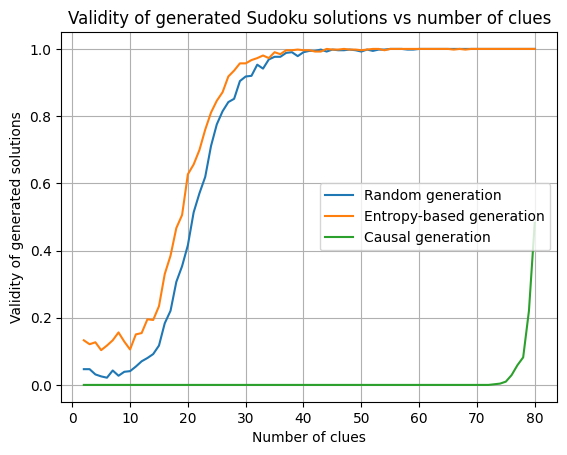

In [13]:
# plot the accuracies
x = range(n*n-1, 1, -1)
plt.plot(x, accuracies['random'], label='Random generation')
plt.plot(x, accuracies['entropy'], label='Entropy-based generation')
plt.plot(x, accuracies['causal'], label='Causal generation')
plt.xlabel('Number of clues')
plt.ylabel('Validity of generated solutions')
plt.title('Validity of generated Sudoku solutions vs number of clues')
plt.legend()
plt.grid()
plt.show()

### A comparison with shuffling tokens

In [14]:
def diffusion_step_shuffle(model, input_ids, src_mask, noise_level, vocab_size):
    batch_size, seqlen = input_ids.shape
    device = input_ids.device

    sampling_eps = 1e-3
    # sample between [sampling_eps, noise_level]; shape [batch_size]
    t = (noise_level - sampling_eps) * torch.rand(batch_size, device=device) + sampling_eps

    # corrupt each token with probability t, unless it is a fixed clue
    move_indices = (torch.rand(batch_size, seqlen, device=device) < t[:, None]) & ~src_mask

    # sample arbitrary replacement token ids
    random_tokens = torch.randint(
        low=0,
        high=vocab_size,
        size=input_ids.shape,
        device=device,
        dtype=input_ids.dtype,
    )

    # replace corrupted positions with random vocab items
    x_t = torch.where(move_indices, random_tokens, input_ids)

    # model predicts original tokens from corrupted sequence
    logits = model(x_t, t)
    targets = input_ids

    loss = torch.nn.functional.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        targets.reshape(-1),
        reduction="none",
    ).reshape(batch_size, seqlen)

    # only train on positions that were corrupted
    loss = loss.masked_fill(~move_indices, 0)

    denom = move_indices.sum().clamp_min(1)
    loss = loss.sum() / denom
    return loss

In [15]:
import torch

@torch.no_grad()
def sample_shuffle(model, input_ids, src_mask, vocab_size, diffusion_steps=20, eps=1e-3):
    """
    model:      called as model(x_t, t) -> logits of shape [bsz, seq, vocab]
    input_ids:  [bsz, seq], contains clue tokens in src_mask positions
    src_mask:   [bsz, seq], True where token is fixed / observed
    vocab_size: size of token vocabulary

    Returns:
        [bsz, seq] sampled solution
    """
    model.eval()
    device = input_ids.device
    batch_size, seq_len = input_ids.shape

    # start from maximum noise: random tokens on all non-clue positions
    xt = input_ids.clone()
    init_noise = torch.randint(
        low=0,
        high=vocab_size,
        size=input_ids.shape,
        device=device,
        dtype=input_ids.dtype,
    )
    xt = torch.where(src_mask, input_ids, init_noise)

    # schedule goes from 1 -> eps
    t_schedule = torch.linspace(1.0, eps, diffusion_steps, device=device)

    for i in range(diffusion_steps):
        t = t_schedule[i].expand(batch_size)

        # predict p(x0 | xt, t)
        logits = model(xt, t)
        x0_hat = torch.distributions.Categorical(logits=logits).sample()

        # keep clues fixed
        x0_hat = torch.where(src_mask, input_ids, x0_hat)

        if i == diffusion_steps - 1:
            # final step: output predicted clean sample
            xt = x0_hat
        else:
            # re-noise to the next noise level
            t_next = t_schedule[i + 1]

            # with probability t_next, replace by random vocab token
            renoise_mask = (
                torch.rand(batch_size, seq_len, device=device) < t_next
            ) & (~src_mask)

            random_tokens = torch.randint(
                low=0,
                high=vocab_size,
                size=input_ids.shape,
                device=device,
                dtype=input_ids.dtype,
            )

            xt = torch.where(renoise_mask, random_tokens, x0_hat)

    return xt

In [16]:
# Training loop
model_shuffle = Transformer(VOCAB_SIZE, d_model=128, n_heads=4, n_layers=4, max_seq_len=MAX_SEQ_LEN, causal=False, time_conditioning=True).to(device)
optimizer = torch.optim.AdamW(model_shuffle.parameters(), lr=2e-3)

batch_size = 256
max_epochs = 10

loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

global_step = 0
model_shuffle.train()
for epoch in range(max_epochs):
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{max_epochs}")
    
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        src_mask = torch.zeros_like(input_ids, dtype=torch.bool, device=input_ids.device)

        loss = diffusion_step_shuffle(
            model_shuffle,
            input_ids,
            src_mask,
            global_step / (max_epochs * len(loader)), # linearly increase noise level from 0 to 1 over the course of training
            vocab_size=VOCAB_SIZE,
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # update tqdm bar with loss
        pbar.set_postfix(loss=loss.item())
        global_step += 1

Epoch 1/10:   0%|          | 0/3907 [00:00<?, ?it/s]

Epoch 10/10: 100%|██████████| 3907/3907 [01:23<00:00, 46.87it/s, loss=1.39]


In [18]:
accuracies_shuffle = []
for clues in range(n*n-1, 1, -1):
    eval_dataset, _, _ = make_sudoku_dataset(batch_size=512, clues=clues, seed=43)
    # Run generation on eval set
    eval_loader = torch.utils.data.DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)
    all_solutions_shuffle, ground_truths, clues = [], [], []
    for batch in tqdm(eval_loader, desc="Generating solutions"):
        input_ids = batch['input_ids'].to(device)
        src_mask = batch['src_mask'].to(device)
        all_solutions_shuffle.append(sample_shuffle(model_shuffle, input_ids, src_mask, VOCAB_SIZE).cpu().numpy().reshape(-1, n, n))
        ground_truths.append(input_ids.cpu().numpy().reshape(-1, n, n))
        clues.append(src_mask.cpu().numpy().reshape(-1, n, n))
    # Print out performance metrics 
    validity_shuffle = is_batch_valid(np.concatenate(all_solutions_shuffle, axis=0), box_rows, box_cols)
    accuracies_shuffle.append(validity_shuffle.mean())

Generating solutions:   0%|          | 0/2 [00:00<?, ?it/s]

Generating solutions: 100%|██████████| 2/2 [00:00<00:00,  9.21it/s]


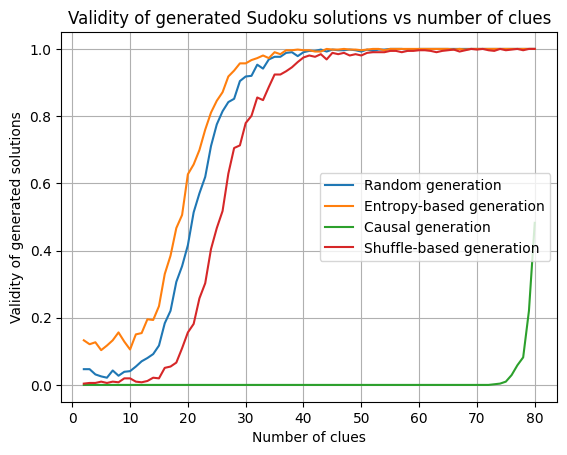

In [19]:
# make a plot comparing the new shuffle-based strategy to the previous ones
plt.plot(range(n*n-1, 1, -1), accuracies['random'], label='Random generation')
plt.plot(range(n*n-1, 1, -1), accuracies['entropy'], label='Entropy-based generation')
plt.plot(range(n*n-1, 1, -1), accuracies['causal'], label='Causal generation')
plt.plot(range(n*n-1, 1, -1), accuracies_shuffle, label='Shuffle-based generation')
plt.xlabel('Number of clues')
plt.ylabel('Validity of generated solutions')
plt.title('Validity of generated Sudoku solutions vs number of clues')
plt.legend()
plt.grid()
plt.show()